In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_theme(style="whitegrid")

print("Libraries loaded.")

Libraries loaded.


In [ ]:
uploaded = files.upload()

files_loaded = {}

for file_name in uploaded.keys():
    files_loaded[file_name] = pd.read_csv(file_name)
    print(file_name, files_loaded[file_name].shape)

Saving milan_cortina_2026_modeling_ready.csv to milan_cortina_2026_modeling_ready.csv
milan_cortina_2026_modeling_ready.csv (387, 34)


In [ ]:
df = files_loaded["milan_cortina_2026_modeling_ready.csv"]

print(df.shape)
display(df.head())

(387, 34)


,Athlete_ID,Athlete_Name,Country,Gender,Age,Age_Band,Sport,Previous_Olympics,Training_Hours_Per_Week,Altitude_Training_m,Body_Fat_Pct,VO2max,Reaction_Time_ms,Career_Injuries,World_Cup_Points_Preseason,Country_GDP_per_capita,Winter_Sport_Tradition_Index,VO2_BodyFat_Efficiency,Experience_Training_Index,GDP_Tradition_Index,Training_Injury_Burden,Missing_Training_Hours_Per_Week,Missing_Altitude_Training_m,Missing_Body_Fat_Pct,Missing_VO2max,Missing_Reaction_Time_ms,Missing_World_Cup_Points_Preseason,MNAR_Reaction_Time_Missing,MNAR_World_Cup_Points_Missing,Medal_Clean,Medal_Binary,Gold_Binary,Podium_Group,North_America_Rivalry
0,MC26_1001,Ben Ogden,USA,M,26.0,23-27,Cross-Country,1,35.6,1687.0,8.9,91.5,190.0,1,356.0,80000,0.82,10.280899,35.6,65600.0,71.2,0,0,1,0,1,0,1,0,Silver,1,0,Silver/Bronze,USA
1,MC26_1002,Loic Meillard,SUI,M,30.0,28-32,Alpine Skiing,3,22.9,2289.0,13.9,71.4,208.0,1,977.0,93000,0.93,5.136691,68.7,86490.0,45.8,0,0,0,0,0,0,0,0,Gold,1,1,Gold,Other
2,MC26_1003,Francesca Lollobrigida,ITA,F,35.0,33-37,Speed Skating,1,29.0,394.0,10.1,82.6,189.0,3,416.0,38000,0.82,8.178218,29.0,31160.0,116.0,0,0,0,0,0,0,0,0,Gold,1,1,Gold,Other
3,MC26_1004,Maria Nilsson,FRA,F,43.0,38+,Ski Jumping,4,26.2,1239.0,9.1,59.3,183.0,2,801.0,48000,0.87,6.516484,104.8,41760.0,78.6,0,0,0,0,0,0,0,0,NaN,0,0,No Medal,Other
4,MC26_1005,Nils Lewis,GER,M,20.0,Under 23,Short Track,0,20.2,67.0,12.3,63.1,187.0,2,393.0,52000,0.88,5.130081,0.0,45760.0,60.6,0,0,0,0,0,0,0,0,NaN,0,0,No Medal,Other


In [ ]:
country_summary = (
    df.groupby("Country")
    .agg(
        Athletes=("Athlete_ID", "count"),
        Medalists=("Medal_Binary", "sum"),
        Golds=("Gold_Binary", "sum"),
        Avg_Training_Hours=("Training_Hours_Per_Week", "mean"),
        Avg_VO2max=("VO2max", "mean"),
        Avg_World_Cup_Points=("World_Cup_Points_Preseason", "mean"),
        Avg_Previous_Olympics=("Previous_Olympics", "mean"),
        GDP=("Country_GDP_per_capita", "mean"),
        Tradition=("Winter_Sport_Tradition_Index", "mean")
    )
    .reset_index()
)

country_summary["Medal_Rate"] = country_summary["Medalists"] / country_summary["Athletes"]
country_summary["Gold_Rate"] = country_summary["Golds"] / country_summary["Athletes"]

country_summary = country_summary.sort_values("Golds", ascending=False)

display(country_summary.head(15))

country_summary.to_csv("business_country_summary.csv", index=False)

,Country,Athletes,Medalists,Golds,Avg_Training_Hours,Avg_VO2max,Avg_World_Cup_Points,Avg_Previous_Olympics,GDP,Tradition,Medal_Rate,Gold_Rate
22,USA,46,23,10,25.715217,68.021739,600.717391,2.282609,80000.0,0.82,0.500000,0.217391
3,CAN,48,18,8,24.834375,67.042708,621.010417,2.375000,55000.0,0.88,0.375000,0.166667
15,NOR,24,11,7,27.266667,74.283333,547.520833,2.375000,95000.0,0.97,0.458333,0.291667
21,SWE,31,9,6,27.093548,73.348387,634.338710,2.483871,56000.0,0.91,0.290323,0.193548
11,ITA,23,9,4,25.352174,69.115217,516.130435,2.478261,38000.0,0.82,0.391304,0.173913
19,SUI,17,6,3,23.723529,66.958824,576.058824,1.764706,93000.0,0.93,0.352941,0.176471
4,CHN,18,3,2,25.255556,68.033333,560.250000,2.722222,13000.0,0.62,0.166667,0.111111
7,FRA,18,5,2,26.088889,70.408333,668.500000,2.444444,48000.0,0.87,0.277778,0.111111
14,NED,16,4,1,27.850000,74.753125,703.218750,2.000000,62000.0,0.85,0.250000,0.062500
2,BRA,6,1,1,24.400000,63.950000,678.583333,2.333333,11000.0,0.04,0.166667,0.166667


In [ ]:
usa_can_exec = country_summary[country_summary["Country"].isin(["USA", "CAN"])].copy()

display(usa_can_exec)

usa_can_exec.to_csv("business_usa_can_executive_comparison.csv", index=False)

,Country,Athletes,Medalists,Golds,Avg_Training_Hours,Avg_VO2max,Avg_World_Cup_Points,Avg_Previous_Olympics,GDP,Tradition,Medal_Rate,Gold_Rate
22,USA,46,23,10,25.715217,68.021739,600.717391,2.282609,80000.0,0.82,0.500,0.217391
3,CAN,48,18,8,24.834375,67.042708,621.010417,2.375000,55000.0,0.88,0.375,0.166667


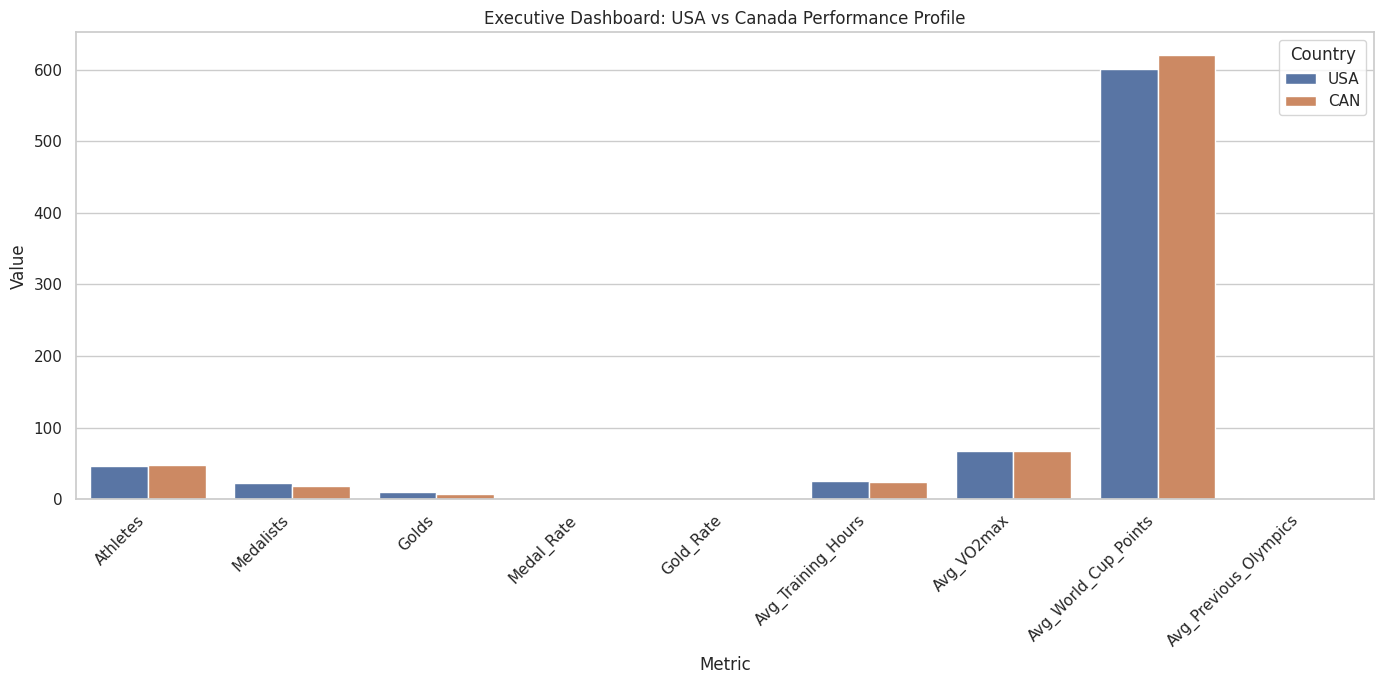

In [ ]:
usa_can_long = usa_can_exec.melt(
    id_vars="Country",
    value_vars=[
        "Athletes",
        "Medalists",
        "Golds",
        "Medal_Rate",
        "Gold_Rate",
        "Avg_Training_Hours",
        "Avg_VO2max",
        "Avg_World_Cup_Points",
        "Avg_Previous_Olympics"
    ],
    var_name="Metric",
    value_name="Value"
)

plt.figure(figsize=(14, 7))
sns.barplot(data=usa_can_long, x="Metric", y="Value", hue="Country")
plt.title("Executive Dashboard: USA vs Canada Performance Profile")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("business_usa_can_dashboard.png", dpi=300)
plt.show()

In [ ]:
usa_can = df[df["Country"].isin(["USA", "CAN"])].copy()

sport_investment = (
    usa_can.groupby(["Country", "Sport"])
    .agg(
        Athletes=("Athlete_ID", "count"),
        Medalists=("Medal_Binary", "sum"),
        Golds=("Gold_Binary", "sum"),
        Avg_World_Cup_Points=("World_Cup_Points_Preseason", "mean"),
        Avg_VO2max=("VO2max", "mean"),
        Avg_Experience=("Previous_Olympics", "mean")
    )
    .reset_index()
)

sport_investment["Medal_Rate"] = sport_investment["Medalists"] / sport_investment["Athletes"]
sport_investment["Gold_Rate"] = sport_investment["Golds"] / sport_investment["Athletes"]

display(sport_investment.sort_values(["Country", "Gold_Rate", "Medal_Rate"], ascending=[True, False, False]))

sport_investment.to_csv("business_sport_investment_table.csv", index=False)

,Country,Sport,Athletes,Medalists,Golds,Avg_World_Cup_Points,Avg_VO2max,Avg_Experience,Medal_Rate,Gold_Rate
3,CAN,Curling,2,2,2,587.500000,51.600000,5.000000,1.000000,1.000000
11,CAN,Speed Skating,7,4,3,709.714286,75.657143,2.714286,0.571429,0.428571
5,CAN,Freestyle Skiing,7,4,2,426.142857,62.228571,1.571429,0.571429,0.285714
9,CAN,Short Track,5,3,1,609.000000,73.880000,2.400000,0.600000,0.200000
6,CAN,Ice Hockey,6,4,0,587.500000,68.416667,2.500000,0.666667,0.000000
10,CAN,Snowboard,9,1,0,481.000000,60.072222,2.222222,0.111111,0.000000
0,CAN,Alpine Skiing,4,0,0,887.500000,63.175000,2.000000,0.000000,0.000000
1,CAN,Biathlon,3,0,0,701.000000,80.733333,2.333333,0.000000,0.000000
2,CAN,Cross-Country,2,0,0,908.500000,82.850000,2.500000,0.000000,0.000000
4,CAN,Figure Skating,1,0,0,587.500000,55.200000,3.000000,0.000000,0.000000


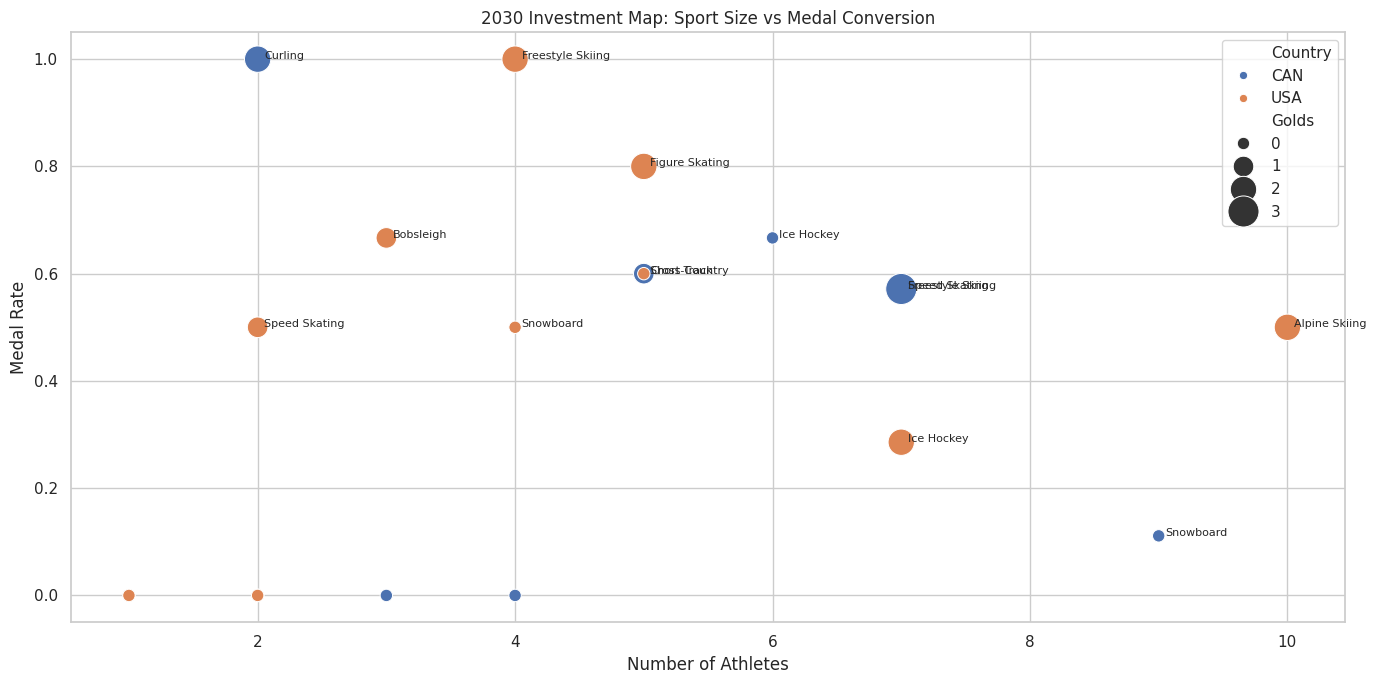

In [ ]:
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=sport_investment,
    x="Athletes",
    y="Medal_Rate",
    size="Golds",
    hue="Country",
    sizes=(80, 500)
)

for _, row in sport_investment.iterrows():
    if row["Medalists"] > 0 or row["Golds"] > 0:
        plt.text(row["Athletes"] + 0.05, row["Medal_Rate"], row["Sport"], fontsize=8)

plt.title("2030 Investment Map: Sport Size vs Medal Conversion")
plt.xlabel("Number of Athletes")
plt.ylabel("Medal Rate")
plt.tight_layout()
plt.savefig("business_2030_sport_investment_map.png", dpi=300)
plt.show()

In [ ]:
head_to_head = (
    sport_investment
    .pivot(index="Sport", columns="Country", values=["Athletes", "Medalists", "Golds", "Medal_Rate", "Gold_Rate"])
)

display(head_to_head)

# Flatten columns
head_to_head.columns = [f"{metric}_{country}" for metric, country in head_to_head.columns]
head_to_head = head_to_head.reset_index()

# Add difference columns where possible
for metric in ["Athletes", "Medalists", "Golds", "Medal_Rate", "Gold_Rate"]:
    usa_col = f"{metric}_USA"
    can_col = f"{metric}_CAN"
    if usa_col in head_to_head.columns and can_col in head_to_head.columns:
        head_to_head[f"{metric}_USA_minus_CAN"] = head_to_head[usa_col] - head_to_head[can_col]

display(head_to_head)

head_to_head.to_csv("business_head_to_head_sport_comparison.csv", index=False)

Athletes       Medalists      Golds      Medal_Rate  \
Country               CAN   USA       CAN  USA   CAN  USA        CAN   
Sport                                                                  
Alpine Skiing         4.0  10.0       0.0  5.0   0.0  2.0   0.000000   
Biathlon              3.0   2.0       0.0  0.0   0.0  0.0   0.000000   
Bobsleigh             NaN   3.0       NaN  2.0   NaN  1.0        NaN   
Cross-Country         2.0   5.0       0.0  3.0   0.0  0.0   0.000000   
Curling               2.0   2.0       2.0  0.0   2.0  0.0   1.000000   
Figure Skating        1.0   5.0       0.0  4.0   0.0  2.0   0.000000   
Freestyle Skiing      7.0   4.0       4.0  4.0   2.0  2.0   0.571429   
Ice Hockey            6.0   7.0       4.0  2.0   0.0  2.0   0.666667   
Luge                  1.0   1.0       0.0  0.0   0.0  0.0   0.000000   
Nordic Combined       1.0   NaN       0.0  NaN   0.0  NaN   0.000000   
Short Track           5.0   1.0       3.0  0.0   1.0  0.0   0.600000   
Snowboard             9.0   4.0       1.0  2.0   0.0  0.0   0.111111   
Speed Skating         7.0   2.0       4.0  1.0   3.0  1.0   0.571429   

                           Gold_Rate            
Country                USA       CAN       USA  
Sport                                           
Alpine Skiing     0.500000  0.000000  0.200000  
Biathlon          0.000000  0.000000  0.000000  
Bobsleigh         0.666667       NaN  0.333333  
Cross-Country     0.600000  0.000000  0.000000  
Curling           0.000000  1.000000  0.000000  
Figure Skating    0.800000  0.000000  0.400000  
Freestyle Skiing  1.000000  0.285714  0.500000  
Ice Hockey        0.285714  0.000000  0.285714  
Luge              0.000000  0.000000  0.000000  
Nordic Combined        NaN  0.000000       NaN  
Short Track       0.000000  0.200000  0.000000  
Snowboard         0.500000  0.000000  0.000000  
Speed Skating     0.500000  0.428571  0.500000

,Sport,Athletes_CAN,Athletes_USA,Medalists_CAN,Medalists_USA,Golds_CAN,Golds_USA,Medal_Rate_CAN,Medal_Rate_USA,Gold_Rate_CAN,Gold_Rate_USA,Athletes_USA_minus_CAN,Medalists_USA_minus_CAN,Golds_USA_minus_CAN,Medal_Rate_USA_minus_CAN,Gold_Rate_USA_minus_CAN
0,Alpine Skiing,4.0,10.0,0.0,5.0,0.0,2.0,0.000000,0.500000,0.000000,0.200000,6.0,5.0,2.0,0.500000,0.200000
1,Biathlon,3.0,2.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,-1.0,0.0,0.0,0.000000,0.000000
2,Bobsleigh,NaN,3.0,NaN,2.0,NaN,1.0,NaN,0.666667,NaN,0.333333,NaN,NaN,NaN,NaN,NaN
3,Cross-Country,2.0,5.0,0.0,3.0,0.0,0.0,0.000000,0.600000,0.000000,0.000000,3.0,3.0,0.0,0.600000,0.000000
4,Curling,2.0,2.0,2.0,0.0,2.0,0.0,1.000000,0.000000,1.000000,0.000000,0.0,-2.0,-2.0,-1.000000,-1.000000
5,Figure Skating,1.0,5.0,0.0,4.0,0.0,2.0,0.000000,0.800000,0.000000,0.400000,4.0,4.0,2.0,0.800000,0.400000
6,Freestyle Skiing,7.0,4.0,4.0,4.0,2.0,2.0,0.571429,1.000000,0.285714,0.500000,-3.0,0.0,0.0,0.428571,0.214286
7,Ice Hockey,6.0,7.0,4.0,2.0,0.0,2.0,0.666667,0.285714,0.000000,0.285714,1.0,-2.0,2.0,-0.380952,0.285714
8,Luge,1.0,1.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000
9,Nordic Combined,1.0,NaN,0.0,NaN,0.0,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
if "feature_importance_best_model.csv" in files_loaded:
    fi = files_loaded["feature_importance_best_model.csv"]

    display(fi.head(20))

    value_col = fi.columns[1]

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi.head(15), x=value_col, y="Feature")
    plt.title("Top Model Signals for Medal Prediction")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.savefig("business_model_feature_importance.png", dpi=300)
    plt.show()
else:
    print("Feature importance file not uploaded.")

Feature importance file not uploaded.


In [ ]:
# Current USA/CAN performance
current = usa_can.groupby("Country").agg(
    Athletes=("Athlete_ID", "count"),
    Medalists=("Medal_Binary", "sum"),
    Golds=("Gold_Binary", "sum")
).reset_index()

current["Medal_Rate"] = current["Medalists"] / current["Athletes"]
current["Gold_Rate"] = current["Golds"] / current["Athletes"]

display(current)

# Scenario:
# For each country, identify sports with medal rate above that country's average.
# Estimate uplift if the country adds 5 athletes into its top-performing sports
# at the current medal rate of those sports.

scenario_rows = []

for country in ["USA", "CAN"]:
    temp = sport_investment[sport_investment["Country"] == country].copy()
    country_avg_medal_rate = current.loc[current["Country"] == country, "Medal_Rate"].iloc[0]

    priority_sports = temp[temp["Medal_Rate"] > country_avg_medal_rate].sort_values("Medal_Rate", ascending=False)

    if priority_sports.empty:
        continue

    top3 = priority_sports.head(3)

    expected_extra_medals = (top3["Medal_Rate"].mean() * 5)
    expected_extra_golds = (top3["Gold_Rate"].mean() * 5)

    scenario_rows.append({
        "Country": country,
        "Current_Medals": current.loc[current["Country"] == country, "Medalists"].iloc[0],
        "Current_Golds": current.loc[current["Country"] == country, "Golds"].iloc[0],
        "Priority_Sports": ", ".join(top3["Sport"].tolist()),
        "Scenario_Assumption": "Add/develop 5 athletes in top 3 above-average medal-rate sports",
        "Expected_Extra_Medals": round(expected_extra_medals, 2),
        "Expected_Extra_Golds": round(expected_extra_golds, 2)
    })

scenario_df = pd.DataFrame(scenario_rows)
display(scenario_df)

scenario_df.to_csv("business_medal_uplift_scenario.csv", index=False)

,Country,Athletes,Medalists,Golds,Medal_Rate,Gold_Rate
0,CAN,48,18,8,0.375,0.166667
1,USA,46,23,10,0.500,0.217391


,Country,Current_Medals,Current_Golds,Priority_Sports,Scenario_Assumption,Expected_Extra_Medals,Expected_Extra_Golds
0,USA,23,10,"Freestyle Skiing, Figure Skating, Bobsleigh",Add/develop 5 athletes in top 3 above-average ...,4.11,2.06
1,CAN,18,8,"Curling, Ice Hockey, Short Track",Add/develop 5 athletes in top 3 above-average ...,3.78,2.00


In [ ]:
print("Business outputs created:")
print("- business_country_summary.csv")
print("- business_usa_can_executive_comparison.csv")
print("- business_sport_investment_table.csv")
print("- business_head_to_head_sport_comparison.csv")
print("- business_medal_uplift_scenario.csv")
print("- business_usa_can_dashboard.png")
print("- business_2030_sport_investment_map.png")

Business outputs created:
- business_country_summary.csv
- business_usa_can_executive_comparison.csv
- business_sport_investment_table.csv
- business_head_to_head_sport_comparison.csv
- business_medal_uplift_scenario.csv
- business_usa_can_dashboard.png
- business_2030_sport_investment_map.png
